In [1]:
import torch
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models.detection.ssd import SSDClassificationHead
from entrega_2.utils.chess_dataset import ChessDataset, get_transforms, collate_fn
from entrega_2.utils.testing import ObjectDetectionEvaluator
from entrega_2.utils.training import ObjectDetectionTrainer, plot_training_history

In [2]:
TRAIN_IMG_DIR = "../../data/chess-pieces-coco/train"
TRAIN_ANN_FILE = "../../data/chess-pieces-coco/train/_annotations.coco.json"
VAL_IMG_DIR = "../../data/chess-pieces-coco/valid"
VAL_ANN_FILE = "../../data/chess-pieces-coco/valid/_annotations.coco.json"
TEST_IMG_DIR = "../../data/chess-pieces-coco/test"
TEST_ANN_FILE = "../../data/chess-pieces-coco/test/_annotations.coco.json"
NUM_CLASES = 13 # 12 piezas de ajedrez + 1 fondo = 13 clases totales

In [3]:
train_dataset = ChessDataset(root=TRAIN_IMG_DIR, annFile=TRAIN_ANN_FILE, transforms=get_transforms(train=True))
val_dataset = ChessDataset(root=VAL_IMG_DIR, annFile=VAL_ANN_FILE, transforms=get_transforms(train=False))
test_dataset = ChessDataset(root=TEST_IMG_DIR, annFile=TEST_ANN_FILE, transforms=get_transforms(train=False))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print(f"Batches de entrenamiento: {len(train_loader)} | Batches de validación: {len(val_loader)} | Batches de pruebas: {len(test_loader)}")

Batches de entrenamiento: 51 | Batches de validación: 15 | Batches de pruebas: 8


In [5]:
NUM_CLASES = 13

model = torchvision.models.detection.ssd300_vgg16(
    weights="DEFAULT"
)

# Reemplazar la cabeza de clasificación
in_channels = [
    layer.in_channels
    for layer in model.head.classification_head.module_list
]

num_anchors = model.anchor_generator.num_anchors_per_location()

model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASES,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Modelo cargado y enviado a: {device}")

Modelo cargado y enviado a: cpu


In [6]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.SGD(
    params,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

trainer = ObjectDetectionTrainer(
    model=model,
    optimizer=optimizer,
    device=device,
    lr_scheduler=lr_scheduler,
    patience=5,
    save_path="mejor_ssd.pth"
)


In [7]:
historial = trainer.fit(train_loader, val_loader, epochs=50)

Comenzando entrenamiento en el dispositivo: cpu

Época 1/50


-> Train Loss: 8.1522 | Val Loss: 5.8901
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 2/50


-> Train Loss: 4.6129 | Val Loss: 3.9729
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 3/50


-> Train Loss: 3.7605 | Val Loss: 3.4589
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 4/50


-> Train Loss: 3.3466 | Val Loss: 3.0261
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 5/50


...

-> Train Loss: 2.0462 | Val Loss: 2.0031
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 47/50


-> Train Loss: 2.0648 | Val Loss: 2.0031
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 48/50


-> Train Loss: 2.0168 | Val Loss: 2.0031
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 49/50


-> Train Loss: 1.9662 | Val Loss: 2.0030
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Época 50/50


-> Train Loss: 1.9726 | Val Loss: 2.0030
Nueva mejor pérdida de validación. Modelo guardado en: mejor_ssd.pth
--------------------------------------------------
Entrenamiento finalizado. Pesos del mejor modelo restaurados.


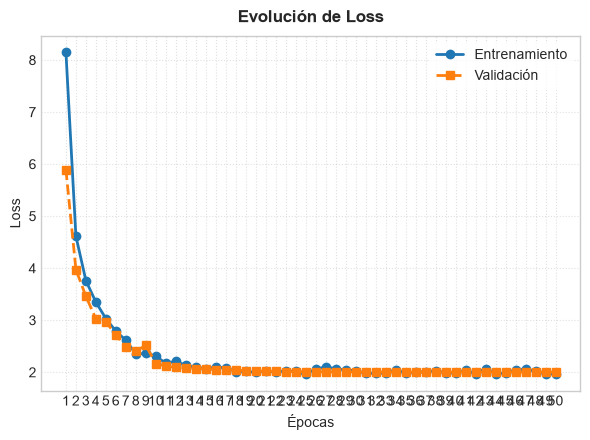

In [8]:
plot_training_history(historial)

In [9]:
state_dict = torch.load("mejor_ssd.pth", weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
CHESS_CLASSES = {
    1:  "Alfil Negro",      # black-bishop
    2:  "Rey Negro",        # black-king
    3:  "Caballo Negro",    # black-knight
    4:  "Peon Negro",       # black-pawn
    5:  "Reina Negra",      # black-queen
    6:  "Torre Negra",      # black-rook
    7:  "Alfil Blanco",     # white-bishop
    8:  "Rey Blanco",       # white-king
    9:  "Caballo Blanco",   # white-knight
    10: "Peon Blanco",      # white-pawn
    11: "Reina Blanca",     # white-queen
    12: "Torre Blanca"      # white-rook
}

In [11]:
evaluador = ObjectDetectionEvaluator(model=model, device=device, class_names=CHESS_CLASSES)

In [12]:
resultados_finales = evaluador.evaluate(test_loader)

Ejecutando inferencia en el dataset de prueba...


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]C:\Users\jhoan\OneDrive\Escritorio\VC proyecto 2\vision-computacional-proyecto\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Evaluating: 100%|██████████| 8/8 [00:10<00:00,  1.29s/it]



RESUMEN DE RENDIMIENTO DE EVALUACIÓN
🔹 mAP @ [0.50:0.95] (Estándar):  0.6839
🔹 mAP @ 0.50 (Permisivo):       0.8931
🔹 mAP @ 0.75 (Estricto):        0.8442
🔹 mAR @ 100 max detections:     0.7957



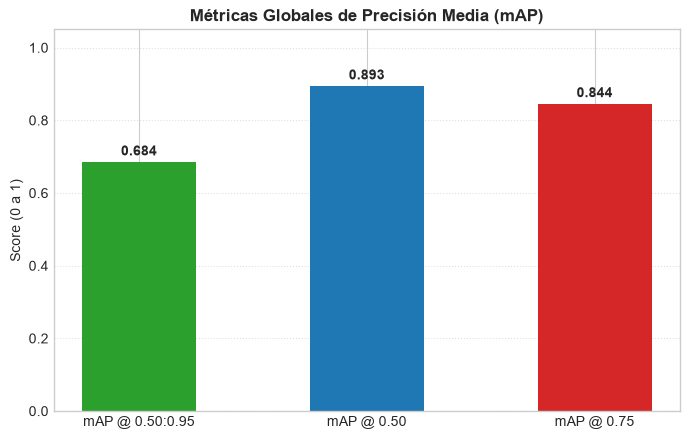

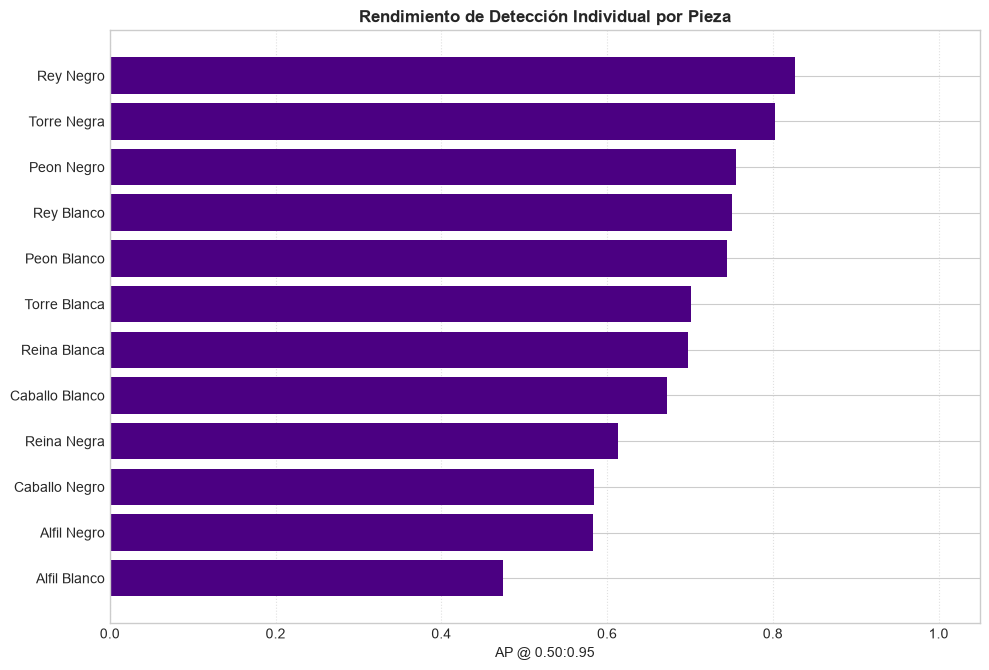

In [13]:
evaluador.plot_global_metrics(resultados_finales)
evaluador.plot_per_class_map(resultados_finales)

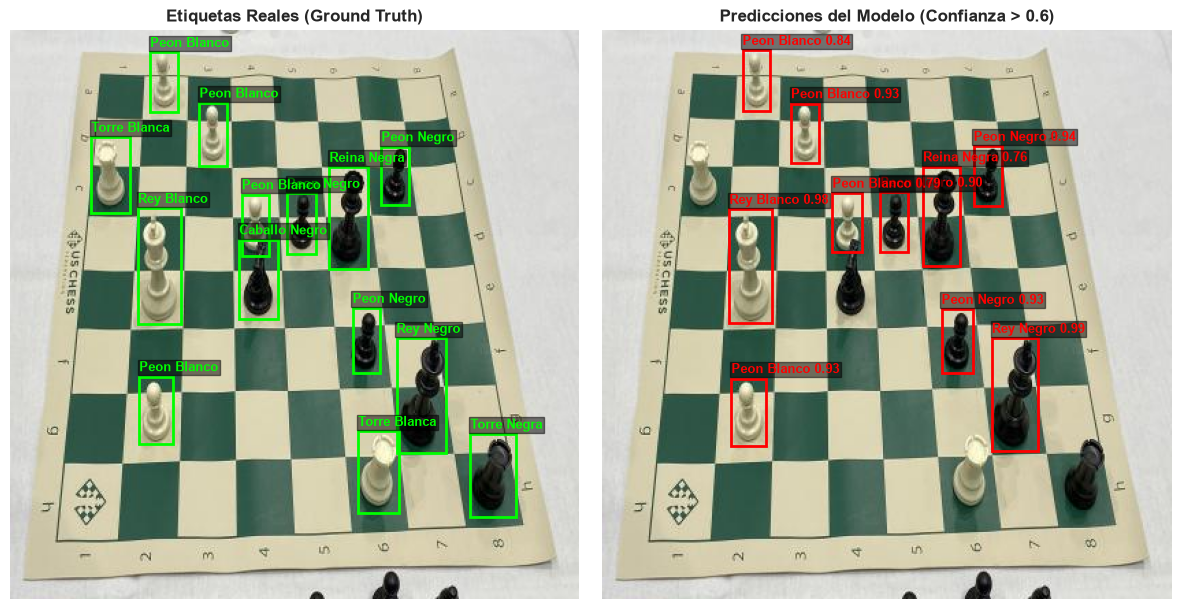

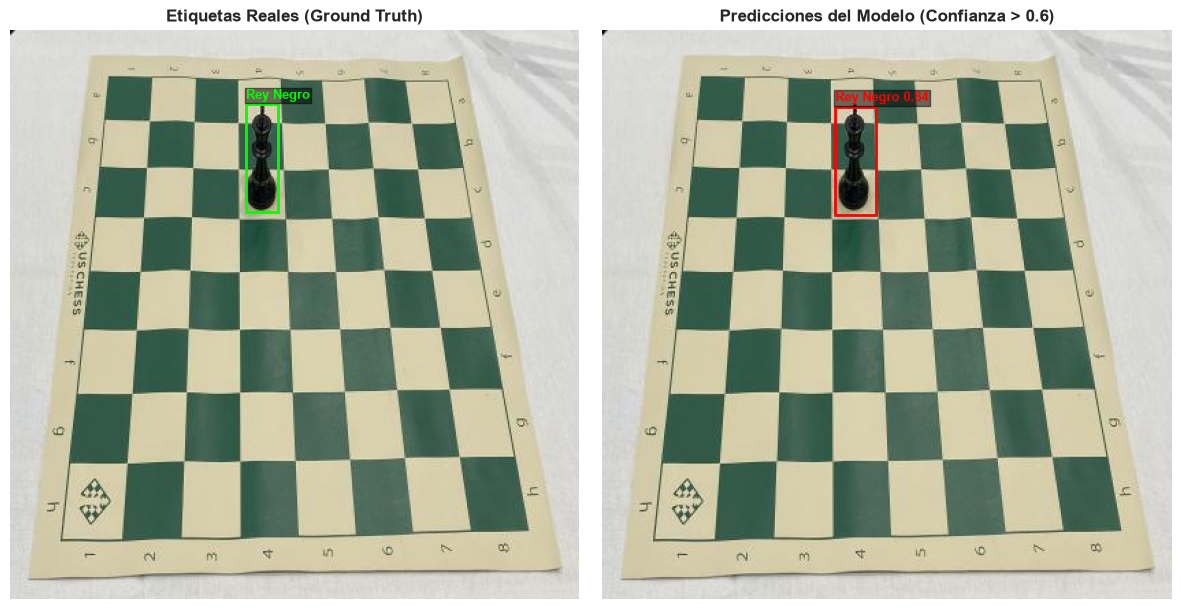

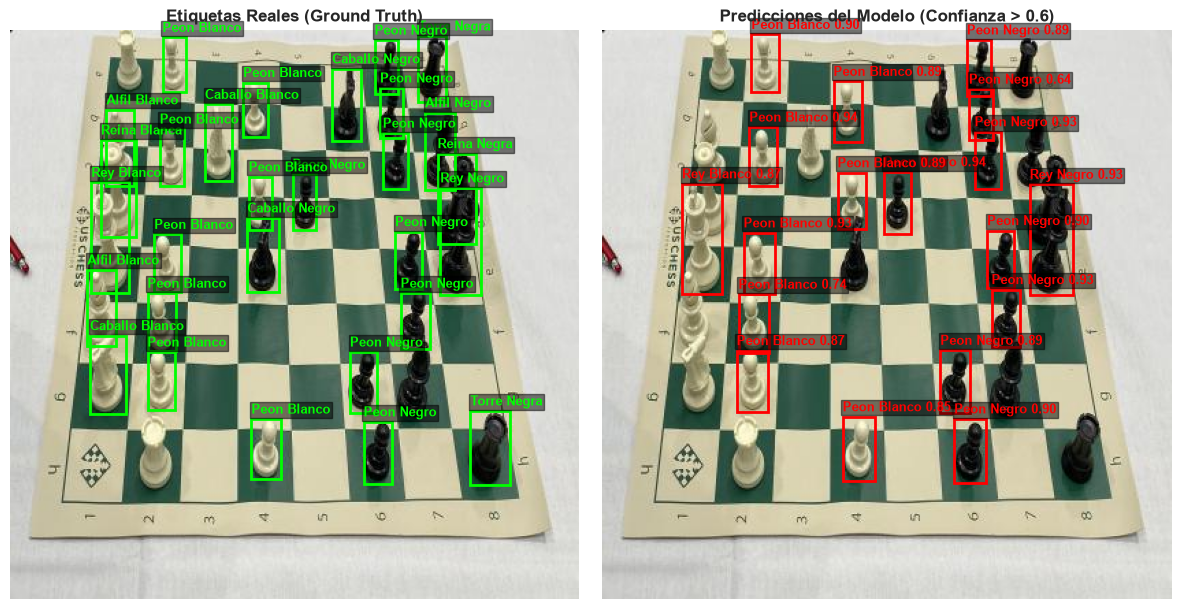

In [15]:
# Ver predicciones reales en imágenes aleatorias contrastadas con sus etiquetas originales
evaluador.visualize_predictions(test_loader, num_images=3, score_threshold=0.6)